In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#(load the dataset from the csv file )
df = pd.read_csv("AmesHousing.csv")

#display the first 5 rows to understand the structure of the data
print("first 5 rows :" , df.head() )

#print the shape of the dataset (number of rows and columns)
print("shape for rows and columns " , df.shape)

#show the dataset info such as column name , data types , and  non-null counts
print("data info :" , df.info())




first 5 rows :    Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SaleP

In [6]:
print("missing values:")
#count missing values in each column and displsy the top 10 columns with most missing values
print (df.isnull().sum().sort_values(ascending=False).head(10))

# check the number of duplicated rows in the dataset
print("duplicate rows:", df.duplicated().sum())

#display descriptive statistics for numerical columns
print("descriptive statistics:", df.describe())

missing values:
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64
duplicate rows: 0
descriptive statistics:             Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall 

In [7]:
#define the target column (house sale price)
target = "SalePrice"

#calculate the p99 percentile of the target column
p99 = df[target].quantile(0.99)

#cap extreme outliers above the 99th percentile
df[target]=df[target].clip(upper=p99)

#function to clean the dataset
def clean_data(df):
  #creat a copy to avoid modifying
  df= df.copy()
  #convert PID to string since it represents an identifier
  df["PID"]= df["PID"].astype(str)
  #convert MS subClass to string since it represents categories
  df["MS SubClass"] = df["MS SubClass"].astype(str)
  # Select numerical columns
  num_cols = df.select_dtypes(include=[np.number]).columns
  #select categorical (text) columns
  cat_cols = df.select_dtypes(include=["object"]).columns
  # Fill missing values in numerical columns with the median
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())
  # Fill missing values in categorical columns with "None"
  df[cat_cols] = df[cat_cols].fillna("None")
  # remove doplicate rows
  df = df.drop_duplicates()
  #recalculate the 99th percentile for the target column
  p99 = df[target].quantile(0.99)
  # cap extreme valuse in the target column
  df[target] = df[target].clip(upper=p99)
  # simple checks to verify the cleaing process
  print("missing in saleprice:", df[target].isnull().sum())
  print("Duplicates:", df.duplicated().sum())
  print("min saleprice:", df[target].min())
  return df
  # apply the cleaning function
clean_data(df)

missing in saleprice: 0
Duplicates: 0
min saleprice: 12789.0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,None,IR1,Lvl,...,0,None,GdPrv,None,0,3,2006,WD,Normal,142500.0
2926,2927,923276100,20,RL,68.0,8885,Pave,None,IR1,Low,...,0,None,MnPrv,None,0,6,2006,WD,Normal,131000.0
2927,2928,923400125,85,RL,62.0,10441,Pave,None,Reg,Lvl,...,0,None,MnPrv,Shed,700,7,2006,WD,Normal,132000.0
2928,2929,924100070,20,RL,77.0,10010,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2006,WD,Normal,170000.0


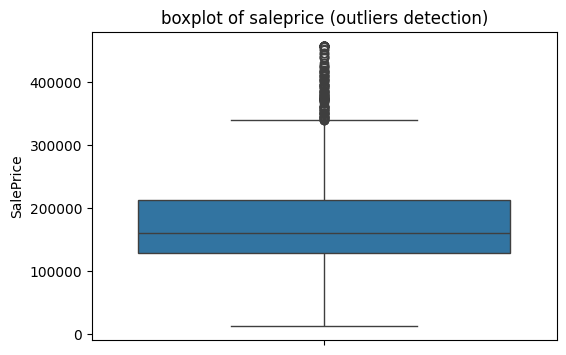

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["SalePrice"])
plt.title("boxplot of saleprice (outliers detection)")
plt.ylabel("SalePrice")
plt.show()